# Mid-Level ML Engineer Interview - ANSWER KEY

## For Interviewers Only

This notebook contains complete solutions and evaluation guidance for each question.

---

## Evaluation Philosophy

**We're assessing HOW candidates think, not just whether they get the "right" answer.**

### Green Flags (What we want to see):
- Asks clarifying questions before diving in
- Explains their reasoning, even for simple problems
- Tests their code incrementally
- Acknowledges trade-offs and alternatives
- Admits when they're unsure and explains how they'd find out
- Clean, readable code (doesn't have to be perfect)

### Yellow Flags (Discuss further):
- Gets stuck but doesn't ask for hints
- Writes code without understanding the problem
- Can't explain why their solution works
- Over-engineers simple problems

### Red Flags (Concerns):
- Cannot implement basic Python constructs (loops, classes)
- No understanding of train/test split purpose
- Cannot interpret accuracy metrics
- Defensive when asked about their approach

---

## Timing Guide

| Section | Allocated | If Running Long |
|---------|-----------|----------------|
| Part 1 (Python) | ~8 min | Skip 1.3 if needed |
| Part 2 (ML) | ~12 min | Focus on 2.1-2.2, abbreviate 2.3 |
| Part 3 (Discussion) | ~5 min | Pick 1-2 most relevant questions |

In [1]:
# ============================================
# SETUP - Same as test notebook
# ============================================

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

print("Setup complete!")

Setup complete!


---

# Part 1: Python Fundamentals - SOLUTIONS

---

## Question 1.1: List Comprehension with Filtering

### Evaluation Criteria:
- **Must have:** Single list comprehension that filters AND transforms
- **Nice to have:** Clean string formatting (f-string or format)
- **Accept:** Minor syntax variations (int() vs round(), different string formatting)

### Common Mistakes to Watch For:
1. Two separate operations (filter then transform) - partial credit
2. Forgetting the `%` symbol
3. Off-by-one on threshold (> vs >=)

In [2]:
# ============================================
# SOLUTION 1.1: List Comprehension
# ============================================

accuracy_scores = [0.92, 0.68, 0.75, 0.81, 0.59, 0.88, 0.73, 0.95]

# BEST SOLUTION: Single comprehension with filter and transform
passing_scores = [f"{int(score * 100)}%" for score in accuracy_scores if score >= 0.75]

print(f"Passing scores: {passing_scores}")
# Output: ['92%', '75%', '81%', '88%', '95%']

Passing scores: ['92%', '75%', '81%', '88%', '95%']


In [3]:
# ============================================
# ALTERNATIVE ACCEPTABLE SOLUTIONS
# ============================================

# Alternative 1: Using round() instead of int()
# Slightly more robust for floating point edge cases
alt1 = [f"{round(score * 100)}%" for score in accuracy_scores if score >= 0.75]
print(f"Alt 1 (round): {alt1}")

# Alternative 2: Using .format() instead of f-string
# Older style but perfectly valid
alt2 = ["{}%".format(int(score * 100)) for score in accuracy_scores if score >= 0.75]
print(f"Alt 2 (format): {alt2}")

# Alternative 3: String concatenation (less elegant but works)
alt3 = [str(int(score * 100)) + "%" for score in accuracy_scores if score >= 0.75]
print(f"Alt 3 (concat): {alt3}")

# PARTIAL CREDIT: Two-step solution (shows understanding but not optimal)
filtered = [score for score in accuracy_scores if score >= 0.75]
partial = [f"{int(s * 100)}%" for s in filtered]
print(f"Partial credit (two steps): {partial}")

Alt 1 (round): ['92%', '75%', '81%', '88%', '95%']
Alt 2 (format): ['92%', '75%', '81%', '88%', '95%']
Alt 3 (concat): ['92%', '75%', '81%', '88%', '95%']
Partial credit (two steps): ['92%', '75%', '81%', '88%', '95%']


### Interviewer Notes for 1.1:

**Follow-up questions if they finish quickly:**
- "What would change if we wanted to include one decimal place (e.g., '92.0%')?"
- "How would you handle None values in the input list?"

**If they struggle:**
- Hint 1: "Can you first write it as a for loop, then convert?"
- Hint 2: "The structure is `[transform(x) for x in list if condition(x)]`"

---

## Question 1.2: Dictionary Aggregation

### Evaluation Criteria:
- **Must have:** Correctly computes average per model
- **Nice to have:** Clean/Pythonic approach (defaultdict, pandas, comprehensions)
- **Accept:** Any working approach - loops are fine!

### What We're Really Testing:
- Can they work with nested data structures?
- Do they think about grouping/aggregation?
- Do they handle the "accumulate then divide" pattern?

In [22]:
# ============================================
# SOLUTION 1.2: Dictionary Aggregation
# ============================================

from statistics import mean


experiment_results = [
    {"model": "RandomForest", "accuracy": 0.89},
    {"model": "LogisticRegression", "accuracy": 0.82},
    {"model": "RandomForest", "accuracy": 0.91},
    {"model": "SVM", "accuracy": 0.87},
    {"model": "LogisticRegression", "accuracy": 0.84},
    {"model": "RandomForest", "accuracy": 0.88},
    {"model": "SVM", "accuracy": 0.85},
]

# ============================================
# SOLUTION A: Simple loop approach (PERFECTLY ACCEPTABLE)
# ============================================
# This is clear and easy to understand - great for interviews!

# Step 1: Collect all accuracies per model
model_accuracies = {}
for result in experiment_results:
    model_name = result["model"]
    accuracy = result["accuracy"]
    
    if model_name not in model_accuracies:
        model_accuracies[model_name] = []
    model_accuracies[model_name].append(accuracy)

# Step 2: Compute averages
avg_by_model = {}
avg_by_model_mean = {}
for model_name, accuracies in model_accuracies.items():
    avg_by_model[model_name] = sum(accuracies) / len(accuracies)
    avg_by_model_mean[model_name] = mean(accuracies)

print(f"Solution A (loops): {avg_by_model}, Mean: {avg_by_model_mean}")
# Output: {'RandomForest': 0.8933..., 'LogisticRegression': 0.83, 'SVM': 0.86}

Solution A (loops): {'RandomForest': 0.8933333333333334, 'LogisticRegression': 0.83, 'SVM': 0.86}, Mean: {'RandomForest': 0.8933333333333333, 'LogisticRegression': 0.83, 'SVM': 0.86}


In [5]:
# ============================================
# SOLUTION B: Using defaultdict (Pythonic)
# ============================================
from collections import defaultdict

model_scores = defaultdict(list)
for result in experiment_results:
    model_scores[result["model"]].append(result["accuracy"])

avg_by_model_b = {model: sum(scores)/len(scores) for model, scores in model_scores.items()}
print(f"Solution B (defaultdict): {avg_by_model_b}")

Solution B (defaultdict): {'RandomForest': 0.8933333333333334, 'LogisticRegression': 0.83, 'SVM': 0.86}


In [6]:
# ============================================
# SOLUTION C: Using Pandas (Most concise for ML engineers)
# ============================================
# This shows pandas fluency - very valuable for ML work!

df = pd.DataFrame(experiment_results)
avg_by_model_c = df.groupby("model")["accuracy"].mean().to_dict()
print(f"Solution C (pandas): {avg_by_model_c}")

Solution C (pandas): {'LogisticRegression': 0.83, 'RandomForest': 0.8933333333333334, 'SVM': 0.86}


In [7]:
# ============================================
# SOLUTION D: One-liner with comprehensions (Advanced)
# ============================================
# Impressive but not expected - shows strong Python skills

models = set(r["model"] for r in experiment_results)
avg_by_model_d = {
    m: sum(r["accuracy"] for r in experiment_results if r["model"] == m) / 
       sum(1 for r in experiment_results if r["model"] == m)
    for m in models
}
print(f"Solution D (comprehension): {avg_by_model_d}")

Solution D (comprehension): {'RandomForest': 0.8933333333333334, 'SVM': 0.86, 'LogisticRegression': 0.83}


### Interviewer Notes for 1.2:

**All four solutions above are equally valid.** Judge on:
1. Does it produce correct results?
2. Can they explain their approach?
3. Is the code readable?

**Follow-up questions:**
- "What's the time complexity of your solution?"
- "If you used pandas, could you do it without pandas? (or vice versa)"

**If they struggle:**
- Hint: "Break it into two steps: first group the data, then compute averages"

---

## Question 1.3: Simple Class with Validation

### Evaluation Criteria:
- **Must have:** Working constructor and `is_acceptable()` method
- **Should have:** Validation that raises ValueError
- **Nice to have:** Clean `__str__` implementation
- **Accept:** Minor issues with string formatting

### What We're Really Testing:
- Basic OOP understanding (classes, self, methods)
- Can they implement simple validation?
- Do they know about dunder methods?

In [8]:
# ============================================
# SOLUTION 1.3: ModelResult Class
# ============================================

class ModelResult:
    """
    Stores a model's name and accuracy score with validation.
    
    This class demonstrates:
    - Constructor with validation
    - Instance methods with default parameters
    - __str__ for string representation
    """
    
    def __init__(self, name: str, accuracy: float):
        """
        Initialize ModelResult with name and accuracy.
        
        Args:
            name: Model name (e.g., "RandomForest")
            accuracy: Accuracy score between 0.0 and 1.0
            
        Raises:
            ValueError: If accuracy is not between 0.0 and 1.0
        """
        # Validation: accuracy must be in valid range
        if not 0.0 <= accuracy <= 1.0:
            raise ValueError(f"Accuracy must be between 0.0 and 1.0, got {accuracy}")
        
        self.name = name
        self.accuracy = accuracy
    
    def is_acceptable(self, threshold: float = 0.8) -> bool:
        """
        Check if accuracy meets the threshold.
        
        Args:
            threshold: Minimum acceptable accuracy (default 0.8 = 80%)
            
        Returns:
            True if accuracy >= threshold, False otherwise
        """
        return self.accuracy >= threshold
    
    def __str__(self) -> str:
        """
        Return formatted string representation.
        
        Returns:
            String like "RandomForest: 89.0%"
        """
        return f"{self.name}: {self.accuracy * 100:.1f}%"


# ============================================
# TEST THE IMPLEMENTATION
# ============================================

# Test basic functionality
result = ModelResult("RandomForest", 0.89)
print(result)  # RandomForest: 89.0%
print(f"Is acceptable (default 0.8): {result.is_acceptable()}")  # True
print(f"Is acceptable (0.9 threshold): {result.is_acceptable(threshold=0.9)}")  # False

# Test validation
try:
    bad_result = ModelResult("BadModel", 1.5)
except ValueError as e:
    print(f"Validation works! Error: {e}")

RandomForest: 89.0%
Is acceptable (default 0.8): True
Is acceptable (0.9 threshold): False
Validation works! Error: Accuracy must be between 0.0 and 1.0, got 1.5


In [9]:
# ============================================
# MINIMAL ACCEPTABLE SOLUTION
# ============================================
# If candidate is running low on time, this is acceptable:

class ModelResultMinimal:
    def __init__(self, name, accuracy):
        if accuracy < 0 or accuracy > 1:
            raise ValueError("Invalid accuracy")
        self.name = name
        self.accuracy = accuracy
    
    def is_acceptable(self, threshold=0.8):
        return self.accuracy >= threshold
    
    def __str__(self):
        return f"{self.name}: {self.accuracy * 100}%"

# Test minimal version
min_result = ModelResultMinimal("Test", 0.85)
print(min_result)
print(min_result.is_acceptable())

Test: 85.0%
True


### Interviewer Notes for 1.3:

**Key things to observe:**
1. Do they remember to use `self`?
2. Do they know how to raise exceptions?
3. Do they understand default parameters?

**Common mistakes (partial credit):**
- Forgetting `self` in method definitions
- Using `print` instead of `return` in `__str__`
- Validation after assignment (works but not ideal)

**If running short on time:** Skip this question and move to Part 2. ML skills are more important for this role.

---

# Part 2: ML Pipeline - SOLUTIONS

---

## Question 2.1: Data Preparation

### Evaluation Criteria:
- **Must have:** Correct train/test split with random_state
- **Should have:** Understands why we split data
- **Nice to have:** Thoughtful reasoning about scaling

### Scaling Discussion:
**Both answers are acceptable** - what matters is the reasoning:
- **Scale:** "I'm using SVM/KNN which are distance-based, so scaling helps"
- **Don't scale:** "Decision trees don't need scaling, and I want to start simple"
- **Either:** "I'll try both and compare" - shows good experimental mindset

In [10]:
# ============================================
# SOLUTION 2.1: Data Preparation
# ============================================

# 1. Load the iris dataset
iris = load_iris()

# 2. Create X (features) and y (target)
X = iris.data  # Shape: (150, 4) - 150 samples, 4 features
y = iris.target  # Shape: (150,) - class labels (0, 1, 2)

print(f"Dataset shape: {X.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


In [11]:
# 3. Split into train/test sets
# random_state=42 ensures reproducibility - same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # Reproducibility
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 120 samples
Test set: 30 samples


In [12]:
# 4. Feature Scaling (OPTIONAL - both approaches are valid)

# OPTION A: With scaling (good for SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)        # Only transform test (no fit!)

print("With scaling:")
print(f"  Train mean: {X_train_scaled.mean(axis=0).round(2)}")
print(f"  Train std: {X_train_scaled.std(axis=0).round(2)}")

# REASONING: 
# "I chose to scale because I plan to try SVM and KNN, which are 
#  distance-based algorithms sensitive to feature magnitudes.
#  Scaling ensures all features contribute equally to the distance calculation."

With scaling:
  Train mean: [ 0. -0. -0. -0.]
  Train std: [1. 1. 1. 1.]


In [13]:
# OPTION B: Without scaling (fine for tree-based models)
# If candidate chooses this, it's also valid!

# REASONING:
# "I chose not to scale because I'm starting with a Decision Tree/Random Forest,
#  which are tree-based models that don't require scaling. Trees split on 
#  individual features, so the scale doesn't affect the splits."

### Key Points to Look For:

1. **Correct split syntax** - `train_test_split(X, y, ...)` with both X and y
2. **random_state included** - Shows understanding of reproducibility
3. **If scaling:** Did they fit on train only? (fit_transform on train, transform on test)
4. **Can explain their choice** - Any reasonable explanation is good

---

## Question 2.2: Model Training and Evaluation

### Evaluation Criteria:
- **Must have:** At least 2 models trained and evaluated
- **Should have:** Correct fit/predict workflow
- **Nice to have:** Loop or function to reduce repetition
- **Bonus:** Thoughtful model selection reasoning

In [14]:
# ============================================
# SOLUTION 2.2: Model Training (Basic Approach)
# ============================================
# This straightforward approach is perfectly acceptable!

# Use scaled data for models that benefit from it
# (or unscaled X_train/X_test if they chose not to scale)

# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print(f"\nBest model: {'Logistic Regression' if lr_accuracy > rf_accuracy else 'Random Forest'}")

Logistic Regression Accuracy: 1.0000
Random Forest Accuracy: 1.0000

Best model: Random Forest


In [15]:
# ============================================
# SOLUTION 2.2: Model Training (DRY/Loop Approach)
# ============================================
# More elegant - shows good coding practices

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=200),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    predictions = model.predict(X_test_scaled)
    
    # Evaluate
    accuracy = accuracy_score(y_test, predictions)
    results[name] = {"model": model, "predictions": predictions, "accuracy": accuracy}
    
    print(f"{name}: {accuracy:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]["accuracy"])
print(f"\nBest performing model: {best_model_name}")

Logistic Regression: 1.0000
Random Forest: 1.0000
K-Nearest Neighbors: 1.0000
SVM: 1.0000

Best performing model: Logistic Regression


In [16]:
# ============================================
# SOLUTION 2.2: Using a Function (Advanced)
# ============================================
# Shows strong software engineering practices

def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    """
    Train a model and return evaluation metrics.
    
    Args:
        model: Scikit-learn classifier
        X_train, X_test: Feature matrices
        y_train, y_test: Target vectors
        
    Returns:
        dict with predictions and accuracy
    """
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    return {"predictions": predictions, "accuracy": accuracy}

# Use the function
dt_result = train_and_evaluate(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)
print(f"Decision Tree: {dt_result['accuracy']:.4f}")

Decision Tree: 1.0000


### Key Points to Look For:

1. **Correct workflow:** fit() on train data, predict() on test data
2. **Doesn't fit on test data** - This would be a red flag
3. **Uses appropriate data:** Scaled if they scaled earlier, unscaled otherwise
4. **Compares results** - Makes a determination about which is better

**Any of these approaches (basic, loop, function) are equally valid!**

---

## Question 2.3: Best Model Analysis

### Evaluation Criteria:
- **Must have:** Confusion matrix and classification report generated
- **Should have:** Can interpret what they see
- **Nice to have:** Insight about which class is hardest and why

Confusion Matrix for Logistic Regression:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]



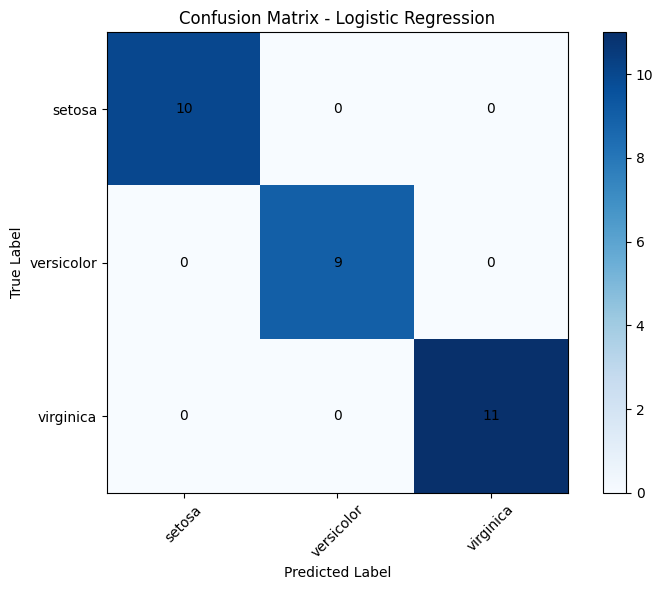

In [17]:
# ============================================
# SOLUTION 2.3: Model Analysis
# ============================================

# Get the best model's predictions
best_predictions = results[best_model_name]["predictions"]

# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)
print(f"Confusion Matrix for {best_model_name}:")
print(cm)
print()

# Visualize confusion matrix (bonus but not required)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
tick_marks = np.arange(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names, rotation=45)
plt.yticks(tick_marks, iris.target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.tight_layout()
plt.show()

In [18]:
# Classification Report
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, best_predictions, target_names=iris.target_names))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Expected Analysis:

**Which class is hardest to classify?**

Typically **versicolor** (class 1) or **virginica** (class 2) are harder to classify than **setosa** (class 0).

**Good candidate answers include:**

1. "Setosa is perfectly classified (no errors in that row/column) while versicolor and virginica have some confusion between them. This suggests these two species have overlapping feature values."

2. "Looking at the confusion matrix, I see some versicolor samples are predicted as virginica (or vice versa). This is likely because these species are more similar in their measurements."

3. "The precision/recall for versicolor is slightly lower than the others, indicating it's harder to distinguish from virginica. They probably occupy similar regions in feature space."

**What we want to see:**
- Can read a confusion matrix (rows = true, columns = predicted)
- Understands what misclassification means
- Can form a hypothesis about WHY (even if they don't know the biology)

---

# Part 3: Discussion Questions - EXPECTED ANSWERS

---

## Question 3.1: Model Selection - What would you try with more time?

### Strong Answers Include:

**Algorithms:**
- Gradient Boosting (XGBoost, LightGBM)
- Neural networks (though overkill for this dataset)
- Ensemble methods (voting classifier)

**Techniques:**
- Cross-validation instead of single train/test split
- Hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
- Feature engineering or selection
- Learning curves to diagnose bias/variance

### Red Flags:
- "Deep learning" without acknowledging it's overkill for 150 samples
- No mention of cross-validation
- Can't name specific techniques

## Question 3.2: Production Considerations

### Strong Answers Include:

**Data considerations:**
- Data validation and quality checks
- Handling missing values, outliers
- Feature drift monitoring

**Model operations:**
- Model versioning and reproducibility
- A/B testing or shadow mode deployment
- Monitoring model performance over time
- Retraining strategy

**Infrastructure:**
- API design and latency requirements
- Logging and observability
- Error handling and fallbacks

**Testing:**
- Unit tests for preprocessing
- Integration tests for the full pipeline
- Performance benchmarks

### Red Flags:
- Only mentions "deploy it" without specifics
- No mention of monitoring
- Doesn't consider data quality issues

## Question 3.3: Debugging - 99% train, 60% test accuracy

### Expected Answer: **Overfitting**

**Strong answers include:**

1. **Diagnosis:** "This is classic overfitting - the model memorized the training data instead of learning generalizable patterns."

2. **Causes:**
   - Model too complex (too many parameters)
   - Not enough training data
   - Not enough regularization
   - Training for too many epochs (if neural network)

3. **Solutions:**
   - Add regularization (L1/L2, dropout)
   - Simplify the model (fewer trees, shallower depth)
   - Get more training data
   - Use cross-validation
   - Early stopping
   - Feature selection (reduce dimensionality)

### Red Flags:
- Doesn't recognize overfitting
- Suggests "train longer" or "add more layers"
- Can't suggest any remediation

---

# Scoring Rubric

## Part 1: Python Fundamentals (25 points)

| Question | Points | Full Credit | Partial Credit |
|----------|--------|-------------|----------------|
| 1.1 List Comprehension | 8 | Single comprehension that filters & transforms | Two-step solution, minor syntax errors |
| 1.2 Dictionary Aggregation | 9 | Correct averages, any approach | Correct grouping but wrong average, minor errors |
| 1.3 Class Implementation | 8 | All requirements met | Missing __str__ or validation, minor issues |

## Part 2: ML Pipeline (50 points)

| Question | Points | Full Credit | Partial Credit |
|----------|--------|-------------|----------------|
| 2.1 Data Preparation | 15 | Correct split, explains scaling choice | Correct split but no reasoning |
| 2.2 Model Training | 20 | 2+ models, correct workflow, comparison | 1 model correct, or minor errors |
| 2.3 Analysis | 15 | Both metrics, interpretation | Metrics without interpretation |

## Part 3: Discussion (25 points)

| Question | Points | Full Credit | Partial Credit |
|----------|--------|-------------|----------------|
| 3.1 Model Selection | 8 | Multiple concrete suggestions | Generic answers |
| 3.2 Production | 9 | Multiple categories covered | Only one area addressed |
| 3.3 Debugging | 8 | Identifies overfitting + solutions | Identifies problem but weak solutions |

## Overall Scoring Guide

| Score | Recommendation |
|-------|----------------|
| 85-100 | Strong hire - Demonstrates solid fundamentals and thinking |
| 70-84 | Hire - Good foundation with some gaps to develop |
| 55-69 | Borderline - Consider role level or follow-up interview |
| Below 55 | No hire - Missing critical skills for mid-level role |

---

# Follow-Up Questions Bank

Use these if the candidate finishes early or you want to probe deeper:

## Python
- "What's the difference between a list and a tuple? When would you use each?"
- "Explain what `*args` and `**kwargs` do."
- "What are generators and when would you use them?"

## ML Fundamentals  
- "What's the difference between precision and recall? When do you care more about one vs the other?"
- "How does a Random Forest differ from a single Decision Tree?"
- "What's the bias-variance tradeoff?"

## Practical Experience
- "Tell me about a time you debugged a model that wasn't performing well."
- "How do you decide which features to include in a model?"
- "What's your approach when inheriting an existing ML project?"